In [1]:
import os, sys, re
import pandas as pd
import multiprocessing
from tqdm import tqdm
from functools import partial
from collections import defaultdict
from argparse import ArgumentParser
#sys.path.append('../')

import rdkit
from rdkit import Chem, RDLogger
from rdkit.Chem import rdChemReactions
# Disable RDKit logging
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)
import time

In [ ]:
template_file_path = "/data/ID_Split42/"

def load_templates(template_file_path):
    template_dicts = {}
    for site in ['real', 'virtual']:
        template_df = pd.read_csv('%s/%s_templates.csv' % (template_file_path, site))
        template_dict = {template_df['Class'][i]: template_df['Template'][i].split('_') for i in template_df.index}
        print ('loaded %s %s templates' % (len(template_dict), site))
        template_dicts[site[0]] = template_dict
    template_infos = pd.read_csv('%s/template_infos.csv' % template_file_path)
    template_infos = {template_infos['Template'][i]: {'edit_site': eval(template_infos['edit_site'][i]), 'change_H': eval(template_infos['change_H'][i]), 'change_C': eval(template_infos['change_C'][i]), 'change_S': eval(template_infos['change_S'][i])} for i in template_infos.index}

    return template_dicts, template_infos


import numpy as np

def get_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    A = [a for a in range(mol.GetNumAtoms())]
    B = []
    for atom in mol.GetAtoms():
        others = []
        bonds = atom.GetBonds()
        for bond in bonds:
            atoms = [bond.GetBeginAtom().GetIdx(), bond.GetEndAtom().GetIdx()]
            other = [a for a in atoms if a != atom.GetIdx()][0]
            others.append(other)
        b = [(atom.GetIdx(), other) for other in sorted(others)]
        B += b
    V = []
    for a in A:
        V += [(a,b) for b in A if a != b and (a,b) not in B]
    return np.array(V), np.array(B)


def get_adm(mol, max_distance = 6):
    mol_size = mol.GetNumAtoms()
    distance_matrix = np.ones((mol_size, mol_size)) * max_distance + 1
    dm = Chem.GetDistanceMatrix(mol)
    dm[dm > 100] = -1 # remote (different molecule)
    dm[dm > max_distance] = max_distance # remote (same molecule)
    dm[dm == -1] = max_distance + 1
    distance_matrix[:dm.shape[0],:dm.shape[1]] = dm
    return distance_matrix


def pad_atom_distance_matrix(adm_list):
    max_size = max([adm.shape[0] for adm in adm_list])
    adm_list = [torch.tensor(np.pad(adm, (0, max_size - adm.shape[0]), 'maximum')).unsqueeze(0).long() for adm in adm_list]
    return torch.cat(adm_list, dim = 0)



def predict(model, bg, adms, bonds_dicts):
    adms = adms.to(device)
    bg = bg.to(device)
    node_feats = bg.ndata.pop('h').to(device)
    edge_feats = bg.edata.pop('e').to(device)
    return model(bg, adms, bonds_dicts, node_feats, edge_feats)

In [3]:
template_dicts, template_infos = load_templates(template_file_path)

loaded 350 real templates
loaded 195 virtual templates


In [6]:
from dgllife.utils import WeaveAtomFeaturizer, CanonicalBondFeaturizer, mol_to_bigraph, smiles_to_bigraph

smiles_to_graph = partial(smiles_to_bigraph, add_self_loop=True)
atom_types = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca', 'Fe',
             'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti',
             'Zn', 'H', 'Li', 'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb',
             'W', 'Ru', 'Nb', 'Re', 'Te', 'Rh', 'Ta', 'Tc', 'Ba', 'Bi', 'Hf', 'Mo', 'U', 'Sm', 'Os', 'Ir',
             'Ce', 'Gd', 'Ga', 'Cs']
node_featurizer = WeaveAtomFeaturizer(atom_types = atom_types)
edge_featurizer = CanonicalBondFeaturizer(self_loop=True)
graph_function = lambda s: smiles_to_graph(s, node_featurizer = node_featurizer, edge_featurizer = edge_featurizer, canonical_atom_order = False)

/raid/aiccg/rbsunoj/anaconda3/envs/rdenv/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sys.path.append('./scripts/')
from models import LocalTransform

In [9]:
Template_rn = len(pd.read_csv(f"{template_file_path}/real_templates.csv"))
Template_vn = len(pd.read_csv(f"{template_file_path}/virtual_templates.csv"))

In [10]:
model = LocalTransform(node_in_feats=80,
              edge_in_feats=13,
              node_out_feats=256,
              edge_hidden_feats=32,
              num_step_message_passing=3,
              attention_heads=8,
              attention_layers=3,
              Template_rn=Template_rn,
              Template_vn=Template_vn)

In [ ]:
import torch
model.load_state_dict(torch.load("models/DeepMech_Split42.pth", map_location='cuda')['model_state_dict'])

<All keys matched successfully>

In [ ]:
device = 'cuda'
model = model.to(device)

In [ ]:

smiles = 'COC(CCCO[P+](c1ccccc1)(c1ccccc1)c1ccccc1)OC.[Br-].BrC(Br)Br' #step5
dglgraph = graph_function(smiles)
dglgraph

Graph(num_nodes=33, num_edges=99,
      ndata_schemes={'h': Scheme(shape=(80,), dtype=torch.float32)}
      edata_schemes={'e': Scheme(shape=(13,), dtype=torch.float32)})

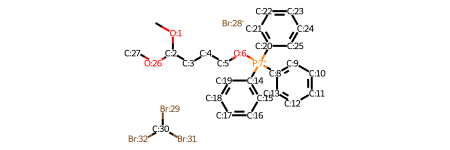

In [543]:
def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol
mol_with_atom_index(Chem.MolFromSmiles(smiles))

In [ ]:
adms = pad_atom_distance_matrix([get_adm(Chem.MolFromSmiles(smiles))])
#adms

In [545]:
v_bonds, r_bonds = get_bonds(smiles)
bonds_dicts = {'virtual': [torch.from_numpy(v_bonds).long()],  'real': [torch.from_numpy(r_bonds).long()]}
#bonds_dicts

In [546]:
len(bonds_dicts['virtual'][0]) + len(bonds_dicts['real'][0])

1056

In [547]:
with torch.no_grad():
    pred_VT, pred_RT, rout_dict_v, rout_dict_r, pred_VI, pred_RI, attentions = predict(model, dglgraph, adms, bonds_dicts)

In [556]:
from torch import nn

In [557]:
pred_v = nn.Softmax(dim=1)(pred_VT)
pred_r = nn.Softmax(dim=1)(pred_RT)

In [560]:
pred_vi = pred_VI[0].cpu()
pred_ri = pred_RI[0].cpu()

In [561]:
from scripts.get_edit import combined_edit

In [562]:
collect_n = 100
pred_types, pred_sites, pred_scores = combined_edit(v_bonds, r_bonds, pred_vi, pred_ri, pred_v, pred_r, collect_n)

In [ ]:
from MechTemplate.template_collector import Collector

In [567]:
reactant = smiles
reagents = ''
sep = 'mix'
collector = Collector(reactant, template_infos, reagents, sep, verbose = 1)

In [522]:
atom_attention = attentions[0]
bond_attention = attentions[1]

In [523]:
atom_att = atom_attention[0].squeeze(0) #taking the first layer, there are three attention layers, 
atom_att.shape

torch.Size([8, 43, 43])

In [524]:
atom_att[0,:,:].shape

torch.Size([43, 43])

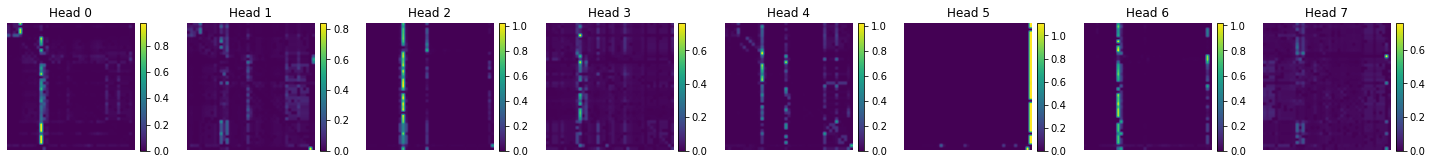

In [525]:
#first visualize all the eight heads
import matplotlib.pyplot as plt
import torch

num_heads = atom_att.shape[0]
fig, axes = plt.subplots(1, num_heads, figsize=(num_heads * 2.5, 3))

for i in range(num_heads):
    ax = axes[i] if num_heads > 1 else axes
    im = ax.imshow(atom_att[i].detach().cpu().numpy(), cmap='viridis')
    ax.set_title(f'Head {i}')
    ax.axis('off')

    # Add colorbar to each subplot
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


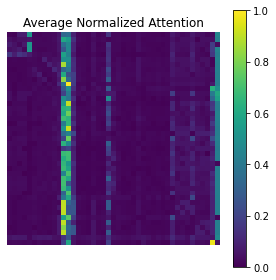

In [526]:
import torch
import matplotlib.pyplot as plt

# Assuming att = attentions[0][0].squeeze(0), shape: [8, 6, 6]
att = attentions[0][0].squeeze(0)

# Step 1: Average across heads (dim=0)
att_avg = att.mean(dim=0)  # Shape: [6, 6]

# Step 2: Normalize (min-max normalization)
att_norm = att_avg - att_avg.min()
att_norm = att_norm / (att_norm.max() + 1e-8)  # avoid div by 0

# Step 3: Visualize
plt.figure(figsize=(4, 4))
im = plt.imshow(att_norm.detach().cpu().numpy(), cmap='viridis')
plt.colorbar(im)
plt.title('Average Normalized Attention')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
#attention visualization (chatgpt): https://chatgpt.com/c/6823183f-9408-800b-81f9-395aebe0413f
import torch
attn = atom_att
# attn: shape [8, 43, 43]
attn_avg = attn.mean(dim=0)          # [43, 43]
attn_per_atom = attn_avg.mean(dim=0) # [43], attention received per atom
attn_per_atom.shape

torch.Size([43])

In [528]:
attn_norm = (attn_per_atom - attn_per_atom.min()) / (attn_per_atom.max() - attn_per_atom.min())
attn_norm.shape

torch.Size([43])

In [529]:
attn_norm

tensor([0.0260, 0.0163, 0.0310, 0.0277, 0.0766, 0.0185, 0.0182, 0.0187, 0.0202,
        0.0330, 0.0649, 1.0000, 0.9490, 0.2269, 0.0103, 0.0079, 0.0000, 0.0388,
        0.0076, 0.0093, 0.2826, 0.0429, 0.0209, 0.0043, 0.0060, 0.0031, 0.0325,
        0.0088, 0.0093, 0.0060, 0.0106, 0.0053, 0.0101, 0.1314, 0.0463, 0.0512,
        0.0528, 0.1165, 0.0523, 0.0501, 0.0459, 0.2469, 0.7414],
       device='cuda:0')

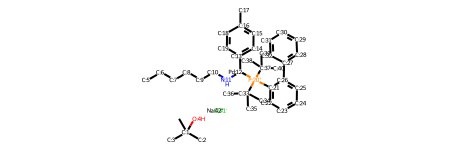

In [531]:
mol = Chem.MolFromSmiles(smiles)
mol_with_atom_index(mol)

In [533]:
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, display
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
from matplotlib.colors import PowerNorm

In [534]:
atom_weights = attn_norm     
c=atom_weights.detach().cpu().numpy().flatten().tolist()
norm = matplotlib.colors.Normalize(vmin=0,vmax=1) #(sum(c)/len(c)))

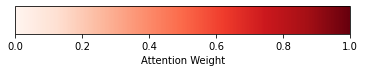

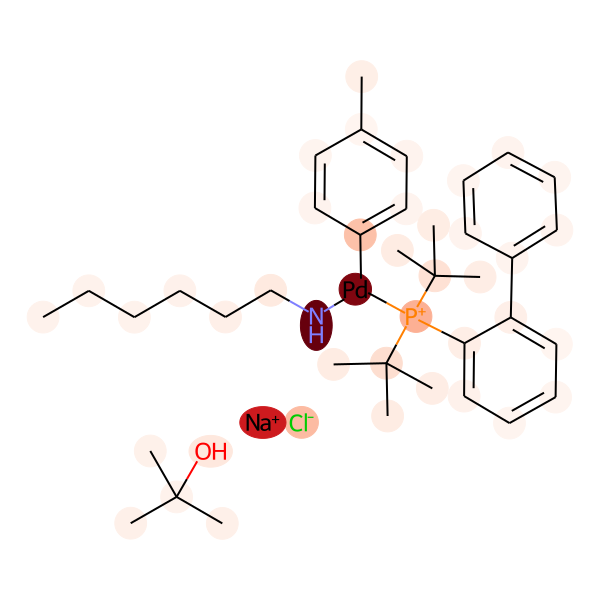

In [535]:
cmap = cm.get_cmap('Reds') #Reds, Blues, BuGn
plt_colors = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
atom_colors = {i: plt_colors.to_rgba(atom_weights[i].data.item()) for i in range(dglgraph.number_of_nodes())}
plt_colors._A = []    

mol = Chem.MolFromSmiles(smiles)
rdDepictor.Compute2DCoords(mol)

drawer = rdMolDraw2D.MolDraw2DSVG(600,600)
drawer.SetFontSize(5)
op = drawer.drawOptions().addAtomIndices=False
drawer.drawOptions().updateAtomPalette({7: (0.5, 0.5, 1)})

# Add colorbar
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
cb = plt.colorbar(plt_colors, cax=ax, orientation='horizontal')
cb.set_label('Attention Weight')
plt.show()


mol = rdMolDraw2D.PrepareMolForDrawing(mol)
drawer.DrawMolecule(mol,highlightAtoms=range(dglgraph.number_of_nodes()),highlightBonds=[],
highlightAtomColors=atom_colors)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()
svg = svg.replace('svg:','')

#Save SVG to a file instead of displaying it
#with open(out_file_name, 'w') as f:
#    f.write(svg)

display(SVG(svg))